In [1]:
%matplotlib inline
import streamlit as st
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import folium 
import geopandas as gpd 
from streamlit_folium import st_folium
from PIL import Image
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import contextily as ctx
import pandas as pd


2026-06-03 00:23:26.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [2]:
gdf_lad = gpd.read_file(r'C:\Users\davic\flc26\data\east_england_local_authorities_lower_level.geojson')

In [3]:
gdf_lad.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   fid           45 non-null     int32   
 1   LAD24CD       45 non-null     str     
 2   LAD24NM       45 non-null     str     
 3   GlobalID      45 non-null     str     
 4   RAvgRankLTLA  45 non-null     int32   
 5   RAvgScorLTLA  45 non-null     int32   
 6   RPLMD10LTLA   45 non-null     int32   
 7   RExtLTLA      45 non-null     int32   
 8   RLocConLTLA   45 non-null     int32   
 9   geometry      45 non-null     geometry
dtypes: geometry(1), int32(6), str(3)
memory usage: 5.1 KB


In [4]:
type(gdf_lad)

geopandas.geodataframe.GeoDataFrame

In [5]:
gdf_lad.head()

,fid,LAD24CD,LAD24NM,GlobalID,RAvgRankLTLA,RAvgScorLTLA,RPLMD10LTLA,RExtLTLA,RLocConLTLA,geometry
0,29,E06000031,Peterborough,{16B4BC85-8428-4DD6-8EB2-CD9243F78312},51,54,65,43,80,"POLYGON ((-0.05802 52.67409, -0.05181 52.6717,..."
1,30,E06000032,Luton,{F8EEC5D2-5BDB-4543-B35D-D9EFAB63B82F},33,45,60,41,67,"POLYGON ((-0.43109 51.92693, -0.43081 51.92692..."
2,31,E06000033,Southend-on-Sea,{127D2EA5-E339-477E-8929-01F69A6941C5},113,89,85,71,55,"MULTIPOLYGON (((0.63996 51.57647, 0.64278 51.5..."
3,32,E06000034,Thurrock,{BC3B3A00-5714-45A3-84A8-C52E5D17E0BB},114,122,145,129,139,"MULTIPOLYGON (((0.39191 51.56593, 0.39198 51.5..."
4,52,E06000055,Bedford,{DAC73DBD-0769-4AC1-A048-2B3F489B3CF1},141,138,131,123,115,"POLYGON ((-0.45293 52.31798, -0.45135 52.3173,..."


In [6]:
gdf_lad.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   fid           45 non-null     int32   
 1   LAD24CD       45 non-null     str     
 2   LAD24NM       45 non-null     str     
 3   GlobalID      45 non-null     str     
 4   RAvgRankLTLA  45 non-null     int32   
 5   RAvgScorLTLA  45 non-null     int32   
 6   RPLMD10LTLA   45 non-null     int32   
 7   RExtLTLA      45 non-null     int32   
 8   RLocConLTLA   45 non-null     int32   
 9   geometry      45 non-null     geometry
dtypes: geometry(1), int32(6), str(3)
memory usage: 5.1 KB


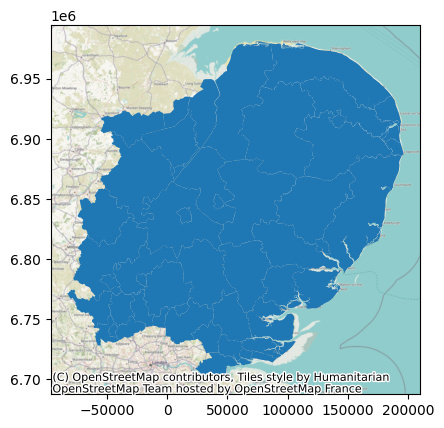

<Figure size 640x480 with 0 Axes>

In [7]:
fig, ax = plt.subplots()
gdf_lad.to_crs(epsg=3857).plot(ax=ax)
ctx.add_basemap(ax)
plt.show()
ctx.add_basemap(ax)
plt.show()

In [8]:
gdf_lad.geometry

0     POLYGON ((-0.05802 52.67409, -0.05181 52.6717,...
1     POLYGON ((-0.43109 51.92693, -0.43081 51.92692...
2     MULTIPOLYGON (((0.63996 51.57647, 0.64278 51.5...
3     MULTIPOLYGON (((0.39191 51.56593, 0.39198 51.5...
4     POLYGON ((-0.45293 52.31798, -0.45135 52.3173,...
5     POLYGON ((-0.28166 52.18934, -0.28132 52.18928...
6     POLYGON ((0.16612 52.23428, 0.16623 52.23425, ...
7     MULTIPOLYGON (((0.30961 52.51346, 0.30968 52.5...
8     MULTIPOLYGON (((0.15717 52.68068, 0.15714 52.6...
9     POLYGON ((-0.39684 52.583, -0.39674 52.58296, ...
10    POLYGON ((0.03709 52.35338, 0.03723 52.35337, ...
11    MULTIPOLYGON (((0.41055 51.65116, 0.41142 51.6...
12    POLYGON ((0.6835 52.08696, 0.6837 52.08694, 0....
13    POLYGON ((0.3357 51.71415, 0.33589 51.71378, 0...
14    MULTIPOLYGON (((0.57106 51.58734, 0.57142 51.5...
15    MULTIPOLYGON (((0.41845 51.85667, 0.41896 51.8...
16    MULTIPOLYGON (((0.96259 51.97716, 0.96287 51.9...
17    POLYGON ((0.17414 51.82059, 0.17451 51.820

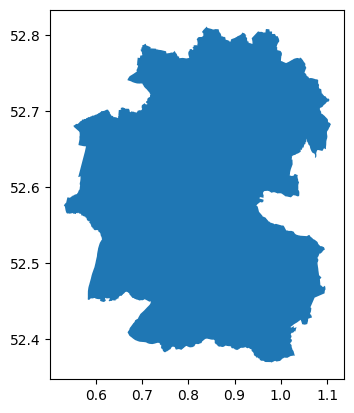

In [9]:
peterborough = gdf_lad['LAD24NM'] == 'Breckland'   
gdf_lad[peterborough].plot()
plt.show()

In [10]:
gdf_lad['LAD24NM'].value_counts() 
lad_names = list(gdf_lad['LAD24NM'].unique())
print(lad_names)

['Peterborough', 'Luton', 'Southend-on-Sea', 'Thurrock', 'Bedford', 'Central Bedfordshire', 'Cambridge', 'East Cambridgeshire', 'Fenland', 'Huntingdonshire', 'South Cambridgeshire', 'Basildon', 'Braintree', 'Brentwood', 'Castle Point', 'Chelmsford', 'Colchester', 'Epping Forest', 'Harlow', 'Maldon', 'Rochford', 'Tendring', 'Uttlesford', 'Broxbourne', 'Dacorum', 'Hertsmere', 'North Hertfordshire', 'Three Rivers', 'Watford', 'Breckland', 'Broadland', 'Great Yarmouth', "King's Lynn and West Norfolk", 'North Norfolk', 'Norwich', 'South Norfolk', 'Babergh', 'Ipswich', 'Mid Suffolk', 'St Albans', 'Welwyn Hatfield', 'East Hertfordshire', 'Stevenage', 'East Suffolk', 'West Suffolk']


In [92]:
gdf_lad.to_file(r'C:\Users\davic\flc26\data\base_gdf.geojson', driver='GeoJSON')

In [75]:
imd_25 = pd.read_csv(r'C:\Users\davic\flc26\data\iod_2025.csv') 
imd_25.info()

<class 'pandas.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 12 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   Local Authority District code (2024)                      296 non-null    str  
 1   Local Authority District name (2024)                      296 non-null    str  
 2   Index of Multiple Deprivation (IMD) Rank                  296 non-null    int64
 3   Income Rank                                               296 non-null    int64
 4   Employment Rank                                           296 non-null    int64
 5   Education Skills and Training Rank                        296 non-null    int64
 6   Health Deprivation and Disability Rank                    296 non-null    int64
 7   Crime Rank                                                296 non-null    int64
 8   Barriers to Housing and Services Rank              

In [76]:
# Subset the DataFrame to include only the columns of interest
imd_25_lad = imd_25[imd_25['Local Authority District name (2024)'].isin(lad_names)]
imd_25_lad.info()
imd_25_lad.head()

<class 'pandas.DataFrame'>
Index: 45 entries, 111 to 295
Data columns (total 12 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   Local Authority District code (2024)                      45 non-null     str  
 1   Local Authority District name (2024)                      45 non-null     str  
 2   Index of Multiple Deprivation (IMD) Rank                  45 non-null     int64
 3   Income Rank                                               45 non-null     int64
 4   Employment Rank                                           45 non-null     int64
 5   Education Skills and Training Rank                        45 non-null     int64
 6   Health Deprivation and Disability Rank                    45 non-null     int64
 7   Crime Rank                                                45 non-null     int64
 8   Barriers to Housing and Services Rank                  

,Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank,Income Rank,Employment Rank,Education Skills and Training Rank,Health Deprivation and Disability Rank,Crime Rank,Barriers to Housing and Services Rank,Living Environment Rank,Income Deprivation Affecting Children Index (IDACI) Rank,Income Deprivation Affecting Older People (IDAOPI) Rank
111,E06000031,Peterborough,51,38,62,28,86,57,49,251,39,65
112,E07000010,Fenland,42,76,51,1,62,120,38,244,67,88
165,E07000011,Huntingdonshire,249,235,235,191,245,228,131,285,241,247
166,E06000055,Bedford,141,128,158,126,125,152,93,182,135,177
167,E07000012,South Cambridgeshire,281,277,280,288,286,279,45,267,281,263


In [77]:
imd_25_lad.columns.tolist()

['Local Authority District code (2024)',
 'Local Authority District name (2024)',
 'Index of Multiple Deprivation (IMD) Rank',
 'Income Rank',
 'Employment Rank',
 'Education Skills and Training Rank',
 'Health Deprivation and Disability Rank',
 'Crime Rank',
 'Barriers to Housing and Services Rank',
 'Living Environment Rank',
 'Income Deprivation Affecting Children Index (IDACI) Rank',
 'Income Deprivation Affecting Older People (IDAOPI) Rank']

In [78]:
# use the actual column name present in imd_25_lad
imd_25_lad['fid'] = imd_25_lad['Local Authority District name (2024)'].map(
    gdf_lad.set_index('LAD24NM')['fid']
)

imd_25_lad.info()

<class 'pandas.DataFrame'>
Index: 45 entries, 111 to 295
Data columns (total 13 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   Local Authority District code (2024)                      45 non-null     str  
 1   Local Authority District name (2024)                      45 non-null     str  
 2   Index of Multiple Deprivation (IMD) Rank                  45 non-null     int64
 3   Income Rank                                               45 non-null     int64
 4   Employment Rank                                           45 non-null     int64
 5   Education Skills and Training Rank                        45 non-null     int64
 6   Health Deprivation and Disability Rank                    45 non-null     int64
 7   Crime Rank                                                45 non-null     int64
 8   Barriers to Housing and Services Rank                  

In [79]:
# rename columns 
imd_25_lad.rename(columns={'Local Authority District code (2024)': 'LAD24CD', 'Local Authority District name (2024)': 'LAD24NM'}, inplace=True)

In [80]:
imd_25_lad.head() 

,LAD24CD,LAD24NM,Index of Multiple Deprivation (IMD) Rank,Income Rank,Employment Rank,Education Skills and Training Rank,Health Deprivation and Disability Rank,Crime Rank,Barriers to Housing and Services Rank,Living Environment Rank,Income Deprivation Affecting Children Index (IDACI) Rank,Income Deprivation Affecting Older People (IDAOPI) Rank,fid
111,E06000031,Peterborough,51,38,62,28,86,57,49,251,39,65,29
112,E07000010,Fenland,42,76,51,1,62,120,38,244,67,88,66
165,E07000011,Huntingdonshire,249,235,235,191,245,228,131,285,241,247,67
166,E06000055,Bedford,141,128,158,126,125,152,93,182,135,177,52
167,E07000012,South Cambridgeshire,281,277,280,288,286,279,45,267,281,263,68


In [16]:
# use the actual column name present in iod_lad
gdf_lad['IMD_25'] = gdf_lad['LAD24NM'].map(
    iod_lad.set_index('Local Authority District name (2024)')['Index of Multiple Deprivation (IMD) Rank']
)

gdf_lad.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   fid           45 non-null     int32   
 1   LAD24CD       45 non-null     str     
 2   LAD24NM       45 non-null     str     
 3   GlobalID      45 non-null     str     
 4   RAvgRankLTLA  45 non-null     int32   
 5   RAvgScorLTLA  45 non-null     int32   
 6   RPLMD10LTLA   45 non-null     int32   
 7   RExtLTLA      45 non-null     int32   
 8   RLocConLTLA   45 non-null     int32   
 9   geometry      45 non-null     geometry
 10  IMD_25        45 non-null     int64   
dtypes: geometry(1), int32(6), int64(1), str(3)
memory usage: 5.5 KB


In [83]:
# Census Data
pop_df = pd.read_csv(r'C:\Users\Davic\flc26\data\population_by_ethnic_groups.csv')
pop_df.head()

,Area code,Area name,"Asian, Asian British or Asian Welsh: Bangladeshi\n(number)","Asian, Asian British or Asian Welsh: Chinese\n(number)","Asian, Asian British or Asian Welsh: Indian\n(number)","Asian, Asian British or Asian Welsh: Pakistani\n(number)","Asian, Asian British or Asian Welsh: Other Asian\n(number)",Asian Sum,"Black, Black British, Black Welsh, Caribbean or African: African\n(number)","Black, Black British, Black Welsh, Caribbean or African: Caribbean\n(number)",...,Mixed or Multiple ethnic groups: White and Black African \n(percent),Mixed or Multiple ethnic groups: White and Black Caribbean\n(percent),Mixed or Multiple ethnic groups: Other Mixed or Multiple ethnic groups\n(percent),"White: English, Welsh, Scottish, Northern Irish or British\n(percent)",White: Irish\n(percent),White: Gypsy or Irish Traveller\n(percent),White: Roma\n(percent),White: Other White\n(percent),Other ethnic group: Arab\n(percent),Other ethnic group: Any other ethnic group\n(percent)
0,E06000001,Hartlepool,278,217,335,297,473,"1,600",327,57,...,0.1,0.2,0.2,95.0,0.2,-,-,1.2,0.3,0.3
1,E06000002,Middlesbrough,595,669,"2,804","8,990","2,032","15,090","3,339",162,...,0.5,0.4,0.5,79.5,0.3,0.1,0.2,2.2,1.0,1.4
2,E06000003,Redcar and Cleveland,158,208,175,283,336,"1,160",182,48,...,0.2,0.2,0.2,96.5,0.3,0.1,-,0.8,0.2,0.2
3,E06000004,Stockton-on-Tees,236,690,"1,812","4,875","1,439","9,052","1,823",130,...,0.2,0.2,0.4,90.3,0.3,0.1,0.1,1.3,0.3,0.6
4,E06000005,Darlington,759,308,"1,086",195,618,"2,966",456,135,...,0.2,0.4,0.3,90.3,0.3,0.4,0.1,3.3,0.3,0.6


In [84]:
pop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 46 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   Area code                                                                         331 non-null    str    
 1   Area name                                                                         331 non-null    str    
 2   Asian, Asian British or Asian Welsh: Bangladeshi
(number)                         331 non-null    str    
 3   Asian, Asian British or Asian Welsh: Chinese
(number)                             331 non-null    str    
 4   Asian, Asian British or Asian Welsh: Indian
(number)                              331 non-null    str    
 5   Asian, Asian British or Asian Welsh: Pakistani
(number)                           331 non-null    str    
 6   Asian, Asian 

In [85]:
pop_df = pop_df[pop_df['Area name'].isin(lad_names)]
pop_df.info()

<class 'pandas.DataFrame'>
Index: 45 entries, 28 to 238
Data columns (total 46 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   Area code                                                                         45 non-null     str    
 1   Area name                                                                         45 non-null     str    
 2   Asian, Asian British or Asian Welsh: Bangladeshi
(number)                         45 non-null     str    
 3   Asian, Asian British or Asian Welsh: Chinese
(number)                             45 non-null     str    
 4   Asian, Asian British or Asian Welsh: Indian
(number)                              45 non-null     str    
 5   Asian, Asian British or Asian Welsh: Pakistani
(number)                           45 non-null     str    
 6   Asian, Asian Briti

In [86]:
pop_df.columns

Index(['Area code', 'Area name',
       'Asian, Asian British or Asian Welsh: Bangladeshi\n(number)',
       'Asian, Asian British or Asian Welsh: Chinese\n(number)',
       'Asian, Asian British or Asian Welsh: Indian\n(number)',
       'Asian, Asian British or Asian Welsh: Pakistani\n(number)',
       'Asian, Asian British or Asian Welsh: Other Asian\n(number)',
       'Asian Sum',
       'Black, Black British, Black Welsh, Caribbean or African: African\n(number)',
       'Black, Black British, Black Welsh, Caribbean or African: Caribbean\n(number)',
       'Black, Black British, Black Welsh, Caribbean or African: Other Black\n(number)',
       'Black Sum',
       'Mixed or Multiple ethnic groups: White and Asian\n(number)',
       'Mixed or Multiple ethnic groups: White and Black African\n(number)',
       'Mixed or Multiple ethnic groups: White and Black Caribbean\n(number)',
       'Mixed or Multiple ethnic groups: Other Mixed or Multiple ethnic groups\n(number)',
       'Mixed Su

In [87]:
# clean commas/spaces and convert to integer (nullable Int64 to keep NaNs if any)
pop_df['Total Sum'] = pd.to_numeric(
    pop_df['Total Sum'].astype(str).str.replace(r'[,\s]', '', regex=True),
    errors='coerce'
).astype('Int64')

pop_df['Total Sum'].head() 

28    215670
29    225261
30    180685
31    175993
51    185224
Name: Total Sum, dtype: Int64

In [23]:
gdf_lad['Population'] = gdf_lad['LAD24NM'].map(
    pop_lad.set_index('Area name')['Total Sum']
    )


In [88]:
pop_df['fid'] = pop_df['Area name'].map(
    gdf_lad.set_index('LAD24NM')['fid']
)

In [89]:
pop_df.head() 

,Area code,Area name,"Asian, Asian British or Asian Welsh: Bangladeshi\n(number)","Asian, Asian British or Asian Welsh: Chinese\n(number)","Asian, Asian British or Asian Welsh: Indian\n(number)","Asian, Asian British or Asian Welsh: Pakistani\n(number)","Asian, Asian British or Asian Welsh: Other Asian\n(number)",Asian Sum,"Black, Black British, Black Welsh, Caribbean or African: African\n(number)","Black, Black British, Black Welsh, Caribbean or African: Caribbean\n(number)",...,Mixed or Multiple ethnic groups: White and Black Caribbean\n(percent),Mixed or Multiple ethnic groups: Other Mixed or Multiple ethnic groups\n(percent),"White: English, Welsh, Scottish, Northern Irish or British\n(percent)",White: Irish\n(percent),White: Gypsy or Irish Traveller\n(percent),White: Roma\n(percent),White: Other White\n(percent),Other ethnic group: Arab\n(percent),Other ethnic group: Any other ethnic group\n(percent),fid
28,E06000031,Peterborough,442,990,"7,169","16,972","5,228","30,801","6,225","1,419",...,0.9,0.9,59.5,0.5,0.3,0.4,14.6,0.4,2.3,29
29,E06000032,Luton,"20,630",901,"12,096","41,143","8,555","83,325","11,774","8,216",...,1.5,1.1,31.8,2.0,0.1,0.4,10.9,0.9,2.5,30
30,E06000033,Southend-on-Sea,"1,615","1,170","2,828","1,765","2,486","9,864","3,590",839,...,0.9,0.8,81.6,0.9,0.1,0.1,4.8,0.2,0.9,31
31,E06000034,Thurrock,"2,502",997,"3,982","2,145","2,579","12,205","16,171","2,174",...,1.0,0.8,66.2,0.6,0.2,0.2,9.6,0.2,1.3,32
51,E06000055,Bedford,"4,486",756,"10,074","5,297","2,650","23,263","5,448","3,227",...,2.0,1.0,64.1,1.0,0.1,0.3,10.2,0.3,1.5,52


In [90]:
# rename columns
pop_df.rename(columns={'Area name': 'LAD24NM', 'Area code': 'LAD24CD'}, inplace=True)

In [91]:
pop_df.head()

,LAD24CD,LAD24NM,"Asian, Asian British or Asian Welsh: Bangladeshi\n(number)","Asian, Asian British or Asian Welsh: Chinese\n(number)","Asian, Asian British or Asian Welsh: Indian\n(number)","Asian, Asian British or Asian Welsh: Pakistani\n(number)","Asian, Asian British or Asian Welsh: Other Asian\n(number)",Asian Sum,"Black, Black British, Black Welsh, Caribbean or African: African\n(number)","Black, Black British, Black Welsh, Caribbean or African: Caribbean\n(number)",...,Mixed or Multiple ethnic groups: White and Black Caribbean\n(percent),Mixed or Multiple ethnic groups: Other Mixed or Multiple ethnic groups\n(percent),"White: English, Welsh, Scottish, Northern Irish or British\n(percent)",White: Irish\n(percent),White: Gypsy or Irish Traveller\n(percent),White: Roma\n(percent),White: Other White\n(percent),Other ethnic group: Arab\n(percent),Other ethnic group: Any other ethnic group\n(percent),fid
28,E06000031,Peterborough,442,990,"7,169","16,972","5,228","30,801","6,225","1,419",...,0.9,0.9,59.5,0.5,0.3,0.4,14.6,0.4,2.3,29
29,E06000032,Luton,"20,630",901,"12,096","41,143","8,555","83,325","11,774","8,216",...,1.5,1.1,31.8,2.0,0.1,0.4,10.9,0.9,2.5,30
30,E06000033,Southend-on-Sea,"1,615","1,170","2,828","1,765","2,486","9,864","3,590",839,...,0.9,0.8,81.6,0.9,0.1,0.1,4.8,0.2,0.9,31
31,E06000034,Thurrock,"2,502",997,"3,982","2,145","2,579","12,205","16,171","2,174",...,1.0,0.8,66.2,0.6,0.2,0.2,9.6,0.2,1.3,32
51,E06000055,Bedford,"4,486",756,"10,074","5,297","2,650","23,263","5,448","3,227",...,2.0,1.0,64.1,1.0,0.1,0.3,10.2,0.3,1.5,52


In [25]:
gdf_lad.head()

,fid,LAD24CD,LAD24NM,GlobalID,RAvgRankLTLA,RAvgScorLTLA,RPLMD10LTLA,RExtLTLA,RLocConLTLA,geometry,IMD_25,Population
0,29,E06000031,Peterborough,{16B4BC85-8428-4DD6-8EB2-CD9243F78312},51,54,65,43,80,"POLYGON ((-0.05802 52.67409, -0.05181 52.6717,...",51,215670
1,30,E06000032,Luton,{F8EEC5D2-5BDB-4543-B35D-D9EFAB63B82F},33,45,60,41,67,"POLYGON ((-0.43109 51.92693, -0.43081 51.92692...",33,225261
2,31,E06000033,Southend-on-Sea,{127D2EA5-E339-477E-8929-01F69A6941C5},113,89,85,71,55,"MULTIPOLYGON (((0.63996 51.57647, 0.64278 51.5...",113,180685
3,32,E06000034,Thurrock,{BC3B3A00-5714-45A3-84A8-C52E5D17E0BB},114,122,145,129,139,"MULTIPOLYGON (((0.39191 51.56593, 0.39198 51.5...",114,175993
4,52,E06000055,Bedford,{DAC73DBD-0769-4AC1-A048-2B3F489B3CF1},141,138,131,123,115,"POLYGON ((-0.45293 52.31798, -0.45135 52.3173,...",141,185224


In [26]:
gdf_lad[['LAD24NM','Population']] 

,LAD24NM,Population
0,Peterborough,215670
1,Luton,225261
2,Southend-on-Sea,180685
3,Thurrock,175993
4,Bedford,185224
5,Central Bedfordshire,294251
6,Cambridge,145674
7,East Cambridgeshire,87763
8,Fenland,102461
9,Huntingdonshire,180832


In [27]:
prostate_df = pd.read_csv(r'C:\Users\davic\flc26\data\prostate_ca.csv') 

In [28]:
prostate_df.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
0,2022,Males,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Prostate,147,Non-standardised,321.5,271.6,377.9,NaN
1,2022,Males,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Prostate,147,Age-standardised,245.5,207.3,288.7,NaN
2,2022,Males,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Prostate,149,Non-standardised,162.4,137.3,190.6,NaN
3,2022,Males,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Prostate,149,Age-standardised,192.9,163.0,226.5,NaN
4,2022,Males,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,Prostate,223,Non-standardised,242.0,211.3,276.0,NaN


In [29]:
pr_list = prostate_df.columns.tolist()
print(pr_list)

['Year', 'Gender', 'Age at diagnosis', 'Geography type', 'Geography code', 'Geography name ', 'NDRS main', 'Count', 'Type of rate', 'Rate', '95% lower confidence interval', '95% upper confidence interval', 'Flag']


In [30]:
ra_list = prostate_df['Type of rate'].unique()
print(ra_list)

<ArrowStringArray>
['Non-standardised', 'Age-standardised']
Length: 2, dtype: str


In [31]:
prostate_df.drop(prostate_df[prostate_df['Type of rate'] == 'Non-standardised'].index, inplace=True) 
prostate_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [32]:
breast_df = pd.read_csv(r'C:\Users\davic\flc26\data\breast_ca.csv') 
breast_df.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
0,2022,Females,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Breast,112,Non-standardised,230.6,189.9,277.5,NaN
1,2022,Females,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Breast,112,Age-standardised,195.1,159.5,236.0,NaN
2,2022,Females,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Breast,135,Non-standardised,139.1,116.6,164.7,NaN
3,2022,Females,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Breast,135,Age-standardised,142.8,119.7,169.0,NaN
4,2022,Females,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,Breast,160,Non-standardised,167.8,142.8,195.9,NaN


In [56]:
breast_df.columns.tolist()

['Year',
 'Gender',
 'Age at diagnosis',
 'Geography type',
 'Geography code',
 'Geography name ',
 'NDRS main',
 'Count',
 'Type of rate',
 'Rate',
 '95% lower confidence interval',
 '95% upper confidence interval',
 'Flag']

In [33]:
breast_df.drop(breast_df[breast_df['Type of rate'] == 'Non-standardised'].index, inplace=True) 
breast_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [34]:
bowel_df = pd.read_csv(r'C:\Users\davic\flc26\data\bowel_ca.csv')
bowel_df.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
0,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Bowel,75,Non-standardised,79.5,62.6,99.7,NaN
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Bowel,75,Age-gender-standardised,60.6,47.5,76.1,NaN
2,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Bowel,126,Non-standardised,66.7,55.6,79.5,NaN
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Bowel,126,Age-gender-standardised,73.9,61.5,88.1,NaN
4,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,Bowel,119,Non-standardised,63.5,52.6,75.9,NaN


In [35]:
bowel_df.drop(bowel_df[bowel_df['Type of rate'] == 'Non-standardised'].index, inplace=True) 
bowel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [36]:
skin_df = pd.read_csv(r'C:\Users\davic\flc26\data\skin_ca.csv')
skin_df.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
0,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Skin cancer,552,Non-standardised,585.4,537.6,636.4,NaN
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Skin cancer,552,Age-gender-standardised,447.2,410.2,486.7,NaN
2,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Skin cancer,898,Non-standardised,475.6,445.0,507.8,NaN
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Skin cancer,898,Age-gender-standardised,537.7,502.8,574.5,NaN
4,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,Skin cancer,724,Non-standardised,386.1,358.5,415.3,NaN


In [37]:
skin_df.drop(skin_df[skin_df['Type of rate'] == 'Non-standardised'].index, inplace=True) 
skin_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [38]:
lung_df = pd.read_csv(r'C:\Users\davic\flc26\data\lung_ca.csv')
lung_df.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
0,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Lung,75,Non-standardised,79.5,62.6,99.7,NaN
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,Lung,75,Age-gender-standardised,58.5,45.9,73.4,NaN
2,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Lung,145,Non-standardised,76.8,64.8,90.4,NaN
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,Lung,145,Age-gender-standardised,85.3,71.8,100.6,NaN
4,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,Lung,128,Non-standardised,68.3,57.0,81.2,NaN


In [39]:
lung_df.drop(lung_df[lung_df['Type of rate'] == 'Non-standardised'].index, inplace=True) 
lung_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [40]:
all_ca_df = pd.read_csv(r'C:\Users\davic\flc26\data\all_ca.csv')
all_ca_df.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
0,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Non-standardised,743.5,689.4,800.6,NaN
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Age-gender-standardised,589.9,546.2,636.1,NaN
2,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Non-standardised,544.5,511.7,578.8,NaN
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Age-gender-standardised,602.0,565.5,640.3,NaN
4,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,All malignant cancers excluding NMSC (ICD10),1103,Non-standardised,588.3,554.0,624.0,NaN


In [41]:
all_ca_df.drop(all_ca_df[all_ca_df['Type of rate'] == 'Non-standardised'].index, inplace=True) 
all_ca_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [42]:
all_ca_df.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Age-gender-standardised,589.9,546.2,636.1,NaN
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Age-gender-standardised,602.0,565.5,640.3,NaN
5,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,All malignant cancers excluding NMSC (ICD10),1103,Age-gender-standardised,650.7,612.6,690.5,NaN
7,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000067,Braintree,All malignant cancers excluding NMSC (ICD10),893,Age-gender-standardised,542.6,507.5,579.6,NaN
9,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000143,Breckland,All malignant cancers excluding NMSC (ICD10),1083,Age-gender-standardised,629.7,592.4,668.9,NaN


In [43]:
ca_list = all_ca_df.columns.tolist() 
print(ca_list)

['Year', 'Gender', 'Age at diagnosis', 'Geography type', 'Geography code', 'Geography name ', 'NDRS main', 'Count', 'Type of rate', 'Rate', '95% lower confidence interval', '95% upper confidence interval', 'Flag']


In [44]:
gdf_lad.head()

,fid,LAD24CD,LAD24NM,GlobalID,RAvgRankLTLA,RAvgScorLTLA,RPLMD10LTLA,RExtLTLA,RLocConLTLA,geometry,IMD_25,Population
0,29,E06000031,Peterborough,{16B4BC85-8428-4DD6-8EB2-CD9243F78312},51,54,65,43,80,"POLYGON ((-0.05802 52.67409, -0.05181 52.6717,...",51,215670
1,30,E06000032,Luton,{F8EEC5D2-5BDB-4543-B35D-D9EFAB63B82F},33,45,60,41,67,"POLYGON ((-0.43109 51.92693, -0.43081 51.92692...",33,225261
2,31,E06000033,Southend-on-Sea,{127D2EA5-E339-477E-8929-01F69A6941C5},113,89,85,71,55,"MULTIPOLYGON (((0.63996 51.57647, 0.64278 51.5...",113,180685
3,32,E06000034,Thurrock,{BC3B3A00-5714-45A3-84A8-C52E5D17E0BB},114,122,145,129,139,"MULTIPOLYGON (((0.39191 51.56593, 0.39198 51.5...",114,175993
4,52,E06000055,Bedford,{DAC73DBD-0769-4AC1-A048-2B3F489B3CF1},141,138,131,123,115,"POLYGON ((-0.45293 52.31798, -0.45135 52.3173,...",141,185224


In [45]:
gdf_lad.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   fid           45 non-null     int32   
 1   LAD24CD       45 non-null     str     
 2   LAD24NM       45 non-null     str     
 3   GlobalID      45 non-null     str     
 4   RAvgRankLTLA  45 non-null     int32   
 5   RAvgScorLTLA  45 non-null     int32   
 6   RPLMD10LTLA   45 non-null     int32   
 7   RExtLTLA      45 non-null     int32   
 8   RLocConLTLA   45 non-null     int32   
 9   geometry      45 non-null     geometry
 10  IMD_25        45 non-null     int64   
 11  Population    45 non-null     Int64   
dtypes: Int64(1), geometry(1), int32(6), int64(1), str(3)
memory usage: 5.9 KB


In [46]:
gdf_pa = gdf_lad[['fid', 'geometry', 'LAD24CD', 'LAD24NM', 'Population', 'IMD_25']]
gdf_pa.head()

,fid,geometry,LAD24CD,LAD24NM,Population,IMD_25
0,29,"POLYGON ((-0.05802 52.67409, -0.05181 52.6717,...",E06000031,Peterborough,215670,51
1,30,"POLYGON ((-0.43109 51.92693, -0.43081 51.92692...",E06000032,Luton,225261,33
2,31,"MULTIPOLYGON (((0.63996 51.57647, 0.64278 51.5...",E06000033,Southend-on-Sea,180685,113
3,32,"MULTIPOLYGON (((0.39191 51.56593, 0.39198 51.5...",E06000034,Thurrock,175993,114
4,52,"POLYGON ((-0.45293 52.31798, -0.45135 52.3173,...",E06000055,Bedford,185224,141


In [47]:
gdf_pa['Ca_Count'] = gdf_pa['LAD24NM'].map(
    all_ca_df.set_index('Geography name ')['Count']
)

In [48]:
gdf_pa.head()

,fid,geometry,LAD24CD,LAD24NM,Population,IMD_25,Ca_Count
0,29,"POLYGON ((-0.05802 52.67409, -0.05181 52.6717,...",E06000031,Peterborough,215670,51,1104
1,30,"POLYGON ((-0.43109 51.92693, -0.43081 51.92692...",E06000032,Luton,225261,33,895
2,31,"MULTIPOLYGON (((0.63996 51.57647, 0.64278 51.5...",E06000033,Southend-on-Sea,180685,113,1083
3,32,"MULTIPOLYGON (((0.39191 51.56593, 0.39198 51.5...",E06000034,Thurrock,175993,114,867
4,52,"POLYGON ((-0.45293 52.31798, -0.45135 52.3173,...",E06000055,Bedford,185224,141,1103


In [49]:
gdf_pa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   fid         45 non-null     int32   
 1   geometry    45 non-null     geometry
 2   LAD24CD     45 non-null     str     
 3   LAD24NM     45 non-null     str     
 4   Population  45 non-null     Int64   
 5   IMD_25      45 non-null     int64   
 6   Ca_Count    45 non-null     int64   
dtypes: Int64(1), geometry(1), int32(1), int64(2), str(2)
memory usage: 3.3 KB


In [50]:
page_1 = gdf_pa.to_file(r'C:\Users\davic\flc26\data\page_1.geojson', index=False)   


In [53]:
ca_br = pd.read_csv(r'C:\Users\davic\flc26\data\all_ca.csv')
ca_br.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           90 non-null     int64  
 1   Gender                         90 non-null     str    
 2   Age at diagnosis               90 non-null     str    
 3   Geography type                 90 non-null     str    
 4   Geography code                 90 non-null     str    
 5   Geography name                 90 non-null     str    
 6   NDRS main                      90 non-null     str    
 7   Count                          90 non-null     int64  
 8   Type of rate                   90 non-null     str    
 9   Rate                           90 non-null     float64
 10  95% lower confidence interval  90 non-null     float64
 11  95% upper confidence interval  90 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [54]:
ca_br.drop(ca_br[ca_br['Type of rate'] == 'Non-standardised'].index, inplace=True) 
ca_br.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
dtypes: 

In [55]:
ca_br.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Age-gender-standardised,589.9,546.2,636.1,NaN
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Age-gender-standardised,602.0,565.5,640.3,NaN
5,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,All malignant cancers excluding NMSC (ICD10),1103,Age-gender-standardised,650.7,612.6,690.5,NaN
7,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000067,Braintree,All malignant cancers excluding NMSC (ICD10),893,Age-gender-standardised,542.6,507.5,579.6,NaN
9,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000143,Breckland,All malignant cancers excluding NMSC (ICD10),1083,Age-gender-standardised,629.7,592.4,668.9,NaN


In [57]:
ca_br.columns.tolist()

['Year',
 'Gender',
 'Age at diagnosis',
 'Geography type',
 'Geography code',
 'Geography name ',
 'NDRS main',
 'Count',
 'Type of rate',
 'Rate',
 '95% lower confidence interval',
 '95% upper confidence interval',
 'Flag']

In [58]:
ca_br['breast'] = ca_br['Geography name '].map(
    breast_df.set_index('Geography name ')['Count']
    )

# gdf_lad['Population'] = gdf_lad['LAD24NM'].map(
#    pop_lad.set_index('Area name')['Total Sum']
#    )

In [59]:
ca_br.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           45 non-null     int64  
 1   Gender                         45 non-null     str    
 2   Age at diagnosis               45 non-null     str    
 3   Geography type                 45 non-null     str    
 4   Geography code                 45 non-null     str    
 5   Geography name                 45 non-null     str    
 6   NDRS main                      45 non-null     str    
 7   Count                          45 non-null     int64  
 8   Type of rate                   45 non-null     str    
 9   Rate                           45 non-null     float64
 10  95% lower confidence interval  45 non-null     float64
 11  95% upper confidence interval  45 non-null     float64
 12  Flag                           0 non-null      float64
 13  bre

In [60]:
ca_br.head() 

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag,breast
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Age-gender-standardised,589.9,546.2,636.1,NaN,112
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Age-gender-standardised,602.0,565.5,640.3,NaN,135
5,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,All malignant cancers excluding NMSC (ICD10),1103,Age-gender-standardised,650.7,612.6,690.5,NaN,160
7,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000067,Braintree,All malignant cancers excluding NMSC (ICD10),893,Age-gender-standardised,542.6,507.5,579.6,NaN,130
9,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000143,Breckland,All malignant cancers excluding NMSC (ICD10),1083,Age-gender-standardised,629.7,592.4,668.9,NaN,162


In [61]:
ca_br['bowel'] = ca_br['Geography name '].map(
    bowel_df.set_index('Geography name ')['Count']
    )

In [62]:
ca_br.head() 

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag,breast,bowel
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Age-gender-standardised,589.9,546.2,636.1,NaN,112,75
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Age-gender-standardised,602.0,565.5,640.3,NaN,135,126
5,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,All malignant cancers excluding NMSC (ICD10),1103,Age-gender-standardised,650.7,612.6,690.5,NaN,160,119
7,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000067,Braintree,All malignant cancers excluding NMSC (ICD10),893,Age-gender-standardised,542.6,507.5,579.6,NaN,130,113
9,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000143,Breckland,All malignant cancers excluding NMSC (ICD10),1083,Age-gender-standardised,629.7,592.4,668.9,NaN,162,129


In [63]:
ca_br['lung'] = ca_br['Geography name '].map(
    lung_df.set_index('Geography name ')['Count']
    )

In [64]:
ca_br['prostate'] = ca_br['Geography name '].map(
    prostate_df.set_index('Geography name ')['Count']
    )

In [65]:
ca_br['skin'] = ca_br['Geography name '].map(
    skin_df.set_index('Geography name ')['Count']
    )

In [66]:
ca_br.head()

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag,breast,bowel,lung,prostate,skin
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Age-gender-standardised,589.9,546.2,636.1,NaN,112,75,75,147,552
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Age-gender-standardised,602.0,565.5,640.3,NaN,135,126,145,149,898
5,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,All malignant cancers excluding NMSC (ICD10),1103,Age-gender-standardised,650.7,612.6,690.5,NaN,160,119,128,223,724
7,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000067,Braintree,All malignant cancers excluding NMSC (ICD10),893,Age-gender-standardised,542.6,507.5,579.6,NaN,130,113,88,157,824
9,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000143,Breckland,All malignant cancers excluding NMSC (ICD10),1083,Age-gender-standardised,629.7,592.4,668.9,NaN,162,129,129,165,662


In [67]:
ca_br['fid'] = ca_br['Geography name '].map(
    gdf_lad.set_index('LAD24NM')['fid']
    )

In [68]:
ca_br.head() 

,Year,Gender,Age at diagnosis,Geography type,Geography code,Geography name,NDRS main,Count,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,Flag,breast,bowel,lung,prostate,skin,fid
1,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000200,Babergh,All malignant cancers excluding NMSC (ICD10),701,Age-gender-standardised,589.9,546.2,636.1,NaN,112,75,75,147,552,190
3,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000066,Basildon,All malignant cancers excluding NMSC (ICD10),1028,Age-gender-standardised,602.0,565.5,640.3,NaN,135,126,145,149,898,90
5,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E06000055,Bedford,All malignant cancers excluding NMSC (ICD10),1103,Age-gender-standardised,650.7,612.6,690.5,NaN,160,119,128,223,724,52
7,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000067,Braintree,All malignant cancers excluding NMSC (ICD10),893,Age-gender-standardised,542.6,507.5,579.6,NaN,130,113,88,157,824,91
9,2022,Persons,All ages,Local Authority Unitary Authories (LAUA),E07000143,Breckland,All malignant cancers excluding NMSC (ICD10),1083,Age-gender-standardised,629.7,592.4,668.9,NaN,162,129,129,165,662,163


In [69]:
ca_br.columns.tolist()

['Year',
 'Gender',
 'Age at diagnosis',
 'Geography type',
 'Geography code',
 'Geography name ',
 'NDRS main',
 'Count',
 'Type of rate',
 'Rate',
 '95% lower confidence interval',
 '95% upper confidence interval',
 'Flag',
 'breast',
 'bowel',
 'lung',
 'prostate',
 'skin',
 'fid']

In [70]:
ca_br.drop(columns=['Year', 'Geography type', 'NDRS main', 'Flag'], inplace=True)

In [71]:
ca_br.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 1 to 89
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         45 non-null     str    
 1   Age at diagnosis               45 non-null     str    
 2   Geography code                 45 non-null     str    
 3   Geography name                 45 non-null     str    
 4   Count                          45 non-null     int64  
 5   Type of rate                   45 non-null     str    
 6   Rate                           45 non-null     float64
 7   95% lower confidence interval  45 non-null     float64
 8   95% upper confidence interval  45 non-null     float64
 9   breast                         45 non-null     int64  
 10  bowel                          45 non-null     int64  
 11  lung                           45 non-null     int64  
 12  prostate                       45 non-null     int64  
 13  ski

In [72]:
# Rename Colums
ca_br.rename(columns={'Count': 'Total_incidence'}, inplace=True)

In [73]:
ca_br.head() 

,Gender,Age at diagnosis,Geography code,Geography name,Total_incidence,Type of rate,Rate,95% lower confidence interval,95% upper confidence interval,breast,bowel,lung,prostate,skin,fid
1,Persons,All ages,E07000200,Babergh,701,Age-gender-standardised,589.9,546.2,636.1,112,75,75,147,552,190
3,Persons,All ages,E07000066,Basildon,1028,Age-gender-standardised,602.0,565.5,640.3,135,126,145,149,898,90
5,Persons,All ages,E06000055,Bedford,1103,Age-gender-standardised,650.7,612.6,690.5,160,119,128,223,724,52
7,Persons,All ages,E07000067,Braintree,893,Age-gender-standardised,542.6,507.5,579.6,130,113,88,157,824,91
9,Persons,All ages,E07000143,Breckland,1083,Age-gender-standardised,629.7,592.4,668.9,162,129,129,165,662,163


In [74]:
ca_br.to_csv(r'C:\Users\davic\flc26\data\overall_incidence.csv', index=False)